<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/07-LangChain/03_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q groq langchain-groq langchain-core langchain-classic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.7 MB/s eta 0:00:00


In [2]:
from langchain_groq import ChatGroq
from google.colab import userdata

GROQ_API_KEY = userdata.get('groq_key')
llm = ChatGroq(
    groq_api_key= GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature= 0.9,
)

In [3]:
import pandas as pd
df= pd.read_csv('Data.csv')

In [4]:
df.head()

,Product,Review
0,Queen Size Sheet Set,I ordered a king size set. My only criticism w...
1,Waterproof Phone Pouch,"I loved the waterproof sac, although the openi..."
2,Luxury Air Mattress,This mattress had a small hole in the top of i...
3,Pillows Insert,This is the best throw pillow fillers on Amazo...
4,Milk Frother Handheld\n,I loved this product. But they only seem to l...


## LLM Chains

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import LLMChain

In [6]:
prompt = ChatPromptTemplate.from_template(
    "What is the best name to describe \
    a company that makes {product}? Just give one name"
)

In [7]:
chain = LLMChain(llm=llm, prompt= prompt)

/tmp/ipykernel_1215/4026764610.py:1: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt= prompt)


In [8]:
product = "Queen Size Sheet Set"
print(chain.run(product))

/tmp/ipykernel_1215/634581513.py:2: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  print(chain.run(product))


"Royal Slumber Co."


## Sequential Chain
---------------------------------
combine multiple chains where the output of the one chain is the input of the next chain.

Two types of sequential chains:
- Simple Sequential Chain: single input/output
- Sequential Chain: multiple inputs/outputs

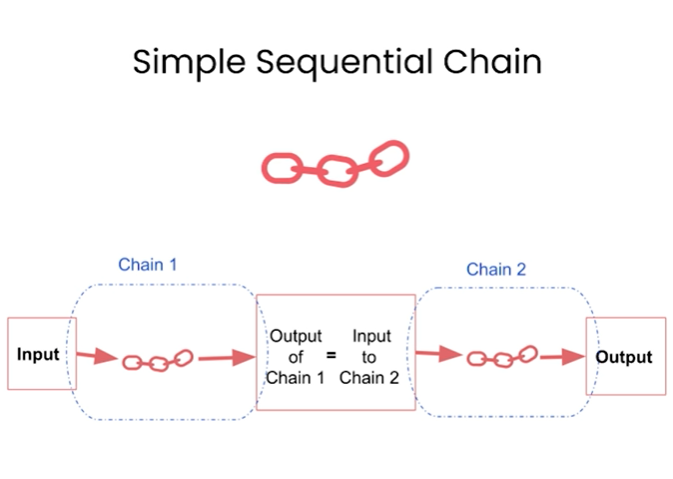

In [9]:
from langchain_classic.chains import SimpleSequentialChain

In [14]:
llm = ChatGroq(
    groq_api_key= GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature= 0.9,
)

# prompt template 1
first_prompt = ChatPromptTemplate.from_template(
    "What is the best name to describe \
    a company that makes {product}? Just give one name"
)

# Chain 1
chain_one = LLMChain(llm=llm, prompt=first_prompt)

In [15]:
# prompt template 2
second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following \
    company:{company_name}"
)
# chain 2
chain_two = LLMChain(llm=llm, prompt=second_prompt)

In [16]:
overall_simple_chain = SimpleSequentialChain(chains=[chain_one, chain_two],
                                             verbose=True
                                            )

In [17]:
overall_simple_chain.run(product)



> Entering new SimpleSequentialChain chain...
"Regal Slumber"
Regal Slumber offers luxurious mattresses and bedding for a restful, peaceful, and rejuvenating sleep experience always guaranteed nightly.

> Finished chain.


'Regal Slumber offers luxurious mattresses and bedding for a restful, peaceful, and rejuvenating sleep experience always guaranteed nightly.'

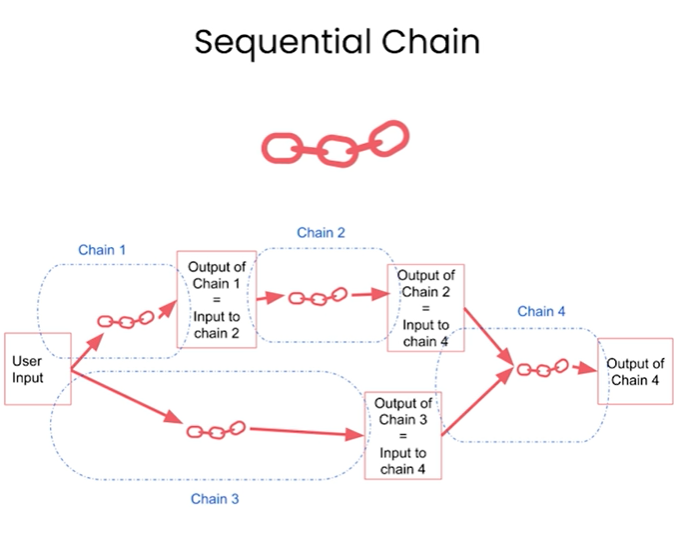

In [18]:
from langchain_classic.chains import SequentialChain

In [25]:
llm = ChatGroq(
    groq_api_key= GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature= 0.9,
)
# prompt template 1: translate to english
first_prompt = ChatPromptTemplate.from_template(
    "Translate the following review to english:"
    "\n\n{Review}" "output should consist of the translation only"
)
# chain 1: input= Review and output= English_Review
chain_one = LLMChain(llm=llm, prompt=first_prompt,
                     output_key="English_Review"
                    )


In [26]:
second_prompt = ChatPromptTemplate.from_template(
    "Can you summarize the following review in 1 sentence:"
    "\n\n{English_Review}"
)
# chain 2: input= English_Review and output= summary
chain_two = LLMChain(llm=llm, prompt=second_prompt,
                     output_key="summary"
                    )

In [27]:
# prompt template 3: translate to english
third_prompt = ChatPromptTemplate.from_template(
    "What language is the following review:\n\n{Review}"
)
# chain 3: input= Review and output= language
chain_three = LLMChain(llm=llm, prompt=third_prompt,
                       output_key="language"
                      )


In [28]:
# prompt template 4: follow up message
fourth_prompt = ChatPromptTemplate.from_template(
    "Write a follow up response to the following "
    "summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}"
)
# chain 4: input= summary, language and output= followup_message
chain_four = LLMChain(llm=llm, prompt=fourth_prompt,
                      output_key="followup_message"
                     )

In [29]:
# overall_chain: input= Review
# and output= English_Review,summary, followup_message
overall_chain = SequentialChain(
    chains=[chain_one, chain_two, chain_three, chain_four],
    input_variables=["Review"],
    output_variables=["English_Review", "summary","followup_message"],
    verbose=True
)

In [30]:
review = df.Review[5]
overall_chain(review)



> Entering new SequentialChain chain...

> Finished chain.


{'Review': "Je trouve le goût médiocre. La mousse ne tient pas, c'est bizarre. J'achète les mêmes dans le commerce et le goût est bien meilleur...\nVieux lot ou contrefaçon !?",
 'English_Review': "I find the taste mediocre. The foam does not hold, it's weird. I buy the same ones in stores and the taste is much better... Old batch or counterfeit!?",
 'summary': "The reviewer is disappointed with their purchase, finding the taste mediocre and the foam faulty, and suspects that they may have received an old or counterfeit batch compared to the same product they've bought in stores.",
 'followup_message': "Je suis vraiment déçu de mon achat, car le goût est tout à fait moyen et la mousse est défectueuse. J'ai déjà acheté ce produit en magasin et il était nettement meilleur, ce qui me fait suspecter que j'ai peut-être reçu un lot vieilli ou contrefait. Je vous conseille de vérifier l'authenticité et la date de péremption de vos produits avant de les vendre en ligne. C'est vraiment dommage,

## Router Chain

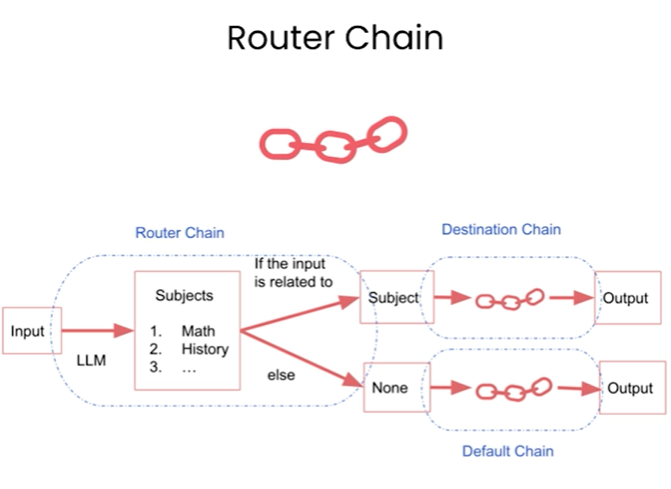

In [31]:
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise\
and easy to understand manner. \
When you don't know the answer to a question you admit\
that you don't know.

Here is a question:
{input}"""


math_template = """You are a very good mathematician. \
You are great at answering math questions. \
You are so good because you are able to break down \
hard problems into their component parts,
answer the component parts, and then put them together\
to answer the broader question.

Here is a question:
{input}"""

history_template = """You are a very good historian. \
You have an excellent knowledge of and understanding of people,\
events and contexts from a range of historical periods. \
You have the ability to think, reflect, debate, discuss and \
evaluate the past. You have a respect for historical evidence\
and the ability to make use of it to support your explanations \
and judgements.

Here is a question:
{input}"""


computerscience_template = """ You are a successful computer scientist.\
You have a passion for creativity, collaboration,\
forward-thinking, confidence, strong problem-solving capabilities,\
understanding of theories and algorithms, and excellent communication \
skills. You are great at answering coding questions. \
You are so good because you know how to solve a problem by \
describing the solution in imperative steps \
that a machine can easily interpret and you know how to \
choose a solution that has a good balance between \
time complexity and space complexity.

Here is a question:
{input}"""

In [34]:
prompt_infos = [
    {
        "name": "physics",
        "description": "Good for answering questions about physics",
        "prompt_template": physics_template
    },
    {
        "name": "math",
        "description": "Good for answering math questions",
        "prompt_template": math_template
    },
    {
        "name": "History",
        "description": "Good for answering history questions",
        "prompt_template": history_template
    },
    {
        "name": "computer science",
        "description": "Good for answering computer science questions",
        "prompt_template": computerscience_template
    }
]

In [32]:
from langchain_classic.chains.router import MultiPromptChain
from langchain_classic.chains.router.llm_router import LLMRouterChain,RouterOutputParser
from langchain_classic.prompts import PromptTemplate

In [33]:
llm = ChatGroq(
    groq_api_key= GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature= 0.9,
)

In [35]:

destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = ChatPromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain

destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = "\n".join(destinations)

In [36]:
#This is when the input has nothing to do with the available options. Fallback option for the LLM
default_prompt = ChatPromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm, prompt=default_prompt)

In [37]:
MULTI_PROMPT_ROUTER_TEMPLATE = """Given a raw text input to a \
language model select the model prompt best suited for the input. \
You will be given the names of the available prompts and a \
description of what the prompt is best suited for. \
You may also revise the original input if you think that revising\
it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ "DEFAULT" or name of the prompt to use in {destinations}
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: The value of “destination” MUST match one of \
the candidate prompts listed below.\
If “destination” does not fit any of the specified prompts, set it to “DEFAULT.”
REMEMBER: "next_inputs" can just be the original input \
if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (remember to include the ```json)>>"""

<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1215/3710404048.py:12: SyntaxWarning: invalid escape sequence '\ '
  "destination": string \ "DEFAULT" or name of the prompt to use in {destinations}


In [38]:
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str
)
router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(),
)

router_chain = LLMRouterChain.from_llm(llm, router_prompt)

In [39]:
chain = MultiPromptChain(router_chain=router_chain,
                         destination_chains=destination_chains,
                         default_chain=default_chain, verbose=True
                        )

/tmp/ipykernel_1215/3038952769.py:1: LangChainDeprecationWarning: The class `MultiPromptChain` was deprecated in LangChain 0.2.12 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. Build routing logic with `create_agent` (e.g. with subagents or prompt-selection middleware). See https://docs.langchain.com/oss/python/langchain/agents
  chain = MultiPromptChain(router_chain=router_chain,


In [40]:
chain.run("What is black body radiation?")



> Entering new MultiPromptChain chain...
physics: {'input': 'What is black body radiation?'}
> Finished chain.


'Black body radiation is a fundamental concept in physics. It refers to the thermal electromagnetic radiation emitted by an object at a certain temperature. The term "black body" doesn\'t mean the object is actually black, but rather that it\'s an idealized object that absorbs all the electromagnetic radiation that hits it, without reflecting or transmitting any of it.\n\nWhen an object is heated, its atoms or molecules start vibrating and rotating, which causes them to emit electromagnetic radiation across a wide range of frequencies. The characteristics of this radiation, such as its intensity and frequency distribution, depend only on the object\'s temperature, not on its composition or other properties.\n\nThe key aspect of black body radiation is that it follows a specific distribution of frequencies, known as Planck\'s law, which was discovered by Max Planck in 1900. This law describes how the intensity of the radiation changes with frequency and temperature, and it\'s a crucial 

In [41]:
chain.run("what is 2 + 2")



> Entering new MultiPromptChain chain...
math: {'input': 'what is 2 + 2'}
> Finished chain.


'To answer this question, let\'s break it down into its simplest component parts.\n\nThe question is asking for the sum of two numbers: 2 and 2.\n\nComponent part 1: What is the value of the first number?\nAnswer: The first number is 2.\n\nComponent part 2: What is the value of the second number?\nAnswer: The second number is also 2.\n\nComponent part 3: What operation is being performed on these two numbers?\nAnswer: The operation being performed is addition, which is denoted by the "+" symbol.\n\nNow, let\'s combine the answers to these component parts to answer the broader question.\n\nWhen we add 2 (the first number) and 2 (the second number), we get:\n2 + 2 = 4\n\nTherefore, the answer to the question is: 4.'

In [42]:
chain.run("Why does every cell in our body contain DNA?")



> Entering new MultiPromptChain chain...
None: {'input': 'What is the role of DNA in cells?'}
> Finished chain.


'DNA (Deoxyribonucleic acid) plays a crucial role in cells as the primary molecule responsible for storing and transmitting genetic information. The main functions of DNA in cells are:\n\n1. **Genetic Information Storage**: DNA contains the genetic instructions for the development, growth, and function of an organism. It encodes the instructions for the synthesis of proteins, which are essential for various cellular processes.\n2. **Transmission of Genetic Traits**: DNA is responsible for passing genetic information from one generation to the next. During cell division, DNA is replicated, and the genetic information is transmitted to the daughter cells.\n3. **Regulation of Gene Expression**: DNA regulates the expression of genes, which involves the transcription of genetic information into RNA and the translation of RNA into proteins. This process is controlled by specific DNA sequences, such as promoters and enhancers.\n4. **Protein Synthesis**: DNA provides the template for the synth